# **BASELINE MODELLING**

## **1. LIBRARIES**

In [11]:
! pip install adlfs azure-storage-blob
! pip install xgboost

In [12]:
# STANDARD LIBRARY
import os
import io

# DATA MANIPULATION AND ANALYSIS
import pandas as pd
import numpy as np

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# AZURE CLOUD STORAGE
from adlfs import AzureBlobFileSystem
from azure.storage.blob import BlobServiceClient

# REGULAR EXPRESSIONS
import re

# TIME SERIES
from sklearn.model_selection import TimeSeriesSplit

# EXTREME GRADIENT BOOST PREDICTOR
import xgboost as xgb
from xgboost import XGBRegressor

# RANDOM FOREST PREDICTOR
from sklearn.ensemble import RandomForestRegressor

# STANDARIZATION
from sklearn.preprocessing import StandardScaler

# EVALUATION METRICS
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# SAVE MODELS
import joblib

In [13]:
# Correctly set pandas display option for max columns and rows
pd.options.display.max_columns = None
pd.options.display.max_rows = None

## **2. LOADING DATASETS FROM AZURE BLOB STORAGE**

In [14]:
def load_csv_from_blob(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    stream = blob_client.download_blob()
    data_bytes = stream.readall()
    data_str = data_bytes.decode("utf-8")
    return pd.read_csv(io.StringIO(data_str))


# Connection configuration
AZURE_STORAGE_ACCOUNT = "researchprojectx24104515"
AZURE_STORAGE_KEY = "bxpexO6i+Hz6n1WiipTn+sTCuLPGMS1BogMERrIrHd16DpQ0GLfQ0R33yrSw4MxsDomq5yNMgw1o+AStlx/MjA=="
connection_string = f"DefaultEndpointsProtocol=https;AccountName={AZURE_STORAGE_ACCOUNT};AccountKey={AZURE_STORAGE_KEY};EndpointSuffix=core.windows.net"
blob_service_client = BlobServiceClient.from_connection_string(connection_string)

fs = AzureBlobFileSystem(
    account_name=AZURE_STORAGE_ACCOUNT,
    account_key=AZURE_STORAGE_KEY
)

In [15]:
# Establish connection to counters dataset
CONTAINER_NAME = "preprocessed"
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

file_name = "counters.csv"
counters = load_csv_from_blob(file_name)
print(f"Loaded '{file_name}' with shape: {counters.shape}")

Loaded 'counters.csv' with shape: (31, 3)


In [16]:
# Establish connection to cycle dataset
CONTAINER_NAME = "preprocessed"
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

file_name = "preprocessed.csv"
data = load_csv_from_blob(file_name)
print(f"Loaded '{file_name}' with shape: {data.shape}")

Loaded 'preprocessed.csv' with shape: (53424, 44)


In [17]:
print("Preprocessed Data:")
print(data.shape)
data.head()

Preprocessed Data:
(53424, 44)


,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,FTF_Aston Quay Merged,FTF_Capel St Mary St Merged,FTF_College St Dame St Merged,FTF_Dame St Merged,FTF_Dolier St Burgh Quay Merged,FTF_Grafton St Monsoon Merged,FTF_Grafton St Nassau St Suffolk St,FTF_Henry St Merged,FTF_Mary St Merged,FTF_Oconnell St Princes St North Merged,FTF_Talbot St Guineys Merged,FTF_Westmoreland St East Fleet St Merged,FTF_Westmoreland St West Merged,WTH_rain,WTH_temp,WTH_wetb,WTH_dewpt,WTH_vappr,WTH_rhum,WTH_msl,TEMP_year,TEMP_holiday,WTH_temp_3h,WTH_rain_int,WTH_dew_spread,WTH_prob_cond,WTH_severe,TEMP_hour_sin,TEMP_hour_cos,TEMP_day_sin,TEMP_day_cos,TEMP_month_sin,TEMP_month_cos,TEMP_weekend,TEMP_mor_peak,TEMP_eve_peak,TEMP_bus_hours
0,2019-01-01 00:00:00,0.0,0.0,12.0,16.0,0.0,0.0,0.0,238.0,0.0,0.0,0.0,140.0,0.0,597.0,163.0,1914.0,0.0,1670.0,1988.0,0.0,9.6,7.8,5.6,9.1,76.0,1035.1,2019,0,0.000000,0,4.0,0,0,0.000000,1.000000,0.781831,0.62349,0.5,0.866025,0,0,0,0
1,2019-01-01 01:00:00,0.0,0.0,17.0,14.0,0.0,0.0,0.0,173.0,0.0,0.0,0.0,215.0,0.0,359.0,102.0,885.0,0.0,767.0,1270.0,0.0,8.6,7.1,5.3,8.9,79.0,1035.1,2019,0,0.000000,0,3.3,0,0,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,0,0,0,0
2,2019-01-01 02:00:00,0.0,0.0,18.0,9.0,0.0,0.0,0.0,121.0,0.0,0.0,0.0,210.0,0.0,317.0,63.0,984.0,0.0,642.0,1589.0,0.0,8.3,6.9,5.3,8.9,81.0,1034.9,2019,0,8.833333,0,3.0,0,0,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,0,0,0,0
3,2019-01-01 03:00:00,0.0,0.0,18.0,15.0,0.0,0.0,0.0,174.0,0.0,0.0,0.0,204.0,0.0,313.0,59.0,935.0,0.0,582.0,1534.0,0.0,9.1,7.6,5.8,9.2,79.0,1035.5,2019,0,8.666667,0,3.3,0,0,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,0,0,0,0
4,2019-01-01 04:00:00,0.0,0.0,12.0,8.0,0.0,0.0,0.0,82.0,0.0,0.0,0.0,88.0,0.0,172.0,46.0,390.0,0.0,143.0,610.0,0.0,9.2,7.7,5.9,9.3,79.0,1035.7,2019,0,8.866667,0,3.3,0,0,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,0,0,0,0


In [18]:
data.tail()

,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,FTF_Aston Quay Merged,FTF_Capel St Mary St Merged,FTF_College St Dame St Merged,FTF_Dame St Merged,FTF_Dolier St Burgh Quay Merged,FTF_Grafton St Monsoon Merged,FTF_Grafton St Nassau St Suffolk St,FTF_Henry St Merged,FTF_Mary St Merged,FTF_Oconnell St Princes St North Merged,FTF_Talbot St Guineys Merged,FTF_Westmoreland St East Fleet St Merged,FTF_Westmoreland St West Merged,WTH_rain,WTH_temp,WTH_wetb,WTH_dewpt,WTH_vappr,WTH_rhum,WTH_msl,TEMP_year,TEMP_holiday,WTH_temp_3h,WTH_rain_int,WTH_dew_spread,WTH_prob_cond,WTH_severe,TEMP_hour_sin,TEMP_hour_cos,TEMP_day_sin,TEMP_day_cos,TEMP_month_sin,TEMP_month_cos,TEMP_weekend,TEMP_mor_peak,TEMP_eve_peak,TEMP_bus_hours
53419,2025-02-03 19:00:00,9.0,19.0,73.0,0.0,0.0,68.0,2690.0,764.0,0.0,0.0,586.0,1206.0,215.0,0.0,494.0,993.0,0.0,0.0,766.0,0.0,11.0,9.3,7.4,10.3,78.0,1012.8,2025,0,10.900000,0,3.6,0,0,-0.965926,0.258819,0.0,1.0,0.866025,0.5,0,0,1,0
53420,2025-02-03 20:00:00,7.0,31.0,55.0,0.0,0.0,50.0,2206.0,1180.0,0.0,0.0,453.0,1301.0,137.0,0.0,323.0,744.0,0.0,0.0,566.0,0.0,11.0,9.4,7.6,10.5,79.0,1012.7,2025,0,10.966667,0,3.4,0,0,-0.866025,0.500000,0.0,1.0,0.866025,0.5,0,0,0,0
53421,2025-02-03 21:00:00,6.0,10.0,42.0,0.0,0.0,30.0,1561.0,406.0,0.0,0.0,337.0,544.0,103.0,0.0,174.0,552.0,0.0,0.0,441.0,0.0,11.0,9.4,7.6,10.5,79.0,1012.1,2025,0,11.000000,0,3.4,0,0,-0.707107,0.707107,0.0,1.0,0.866025,0.5,0,0,0,0
53422,2025-02-03 22:00:00,4.0,7.0,41.0,0.0,0.0,27.0,1483.0,236.0,0.0,0.0,302.0,513.0,139.0,0.0,118.0,393.0,0.0,0.0,403.0,0.0,11.1,9.5,7.8,10.6,80.0,1011.3,2025,0,11.033333,0,3.3,0,0,-0.500000,0.866025,0.0,1.0,0.866025,0.5,0,0,0,0
53423,2025-02-03 23:00:00,2.0,2.0,14.0,0.0,0.0,24.0,1241.0,341.0,0.0,0.0,165.0,286.0,78.0,0.0,56.0,259.0,0.0,0.0,277.0,0.0,11.1,9.6,8.0,10.8,81.0,1011.2,2025,0,11.066667,0,3.1,0,0,-0.258819,0.965926,0.0,1.0,0.866025,0.5,0,0,0,0


## **3. DEFINE FEATURE CATEGORIES**

In [19]:
print(data.columns)

Index(['date and time', 'CYC_Clontarf James Larkin Rd',
       'CYC_Clontarf Pebble Beach Carpark', 'CYC_Grove Road Totem',
       'CYC_North Strand Rd N B', 'CYC_Richmond Street Cyclists 1 Merged',
       'CYC_Richmond Street Cyclists 2 Merged', 'FTF_Aston Quay Merged',
       'FTF_Capel St Mary St Merged', 'FTF_College St Dame St Merged',
       'FTF_Dame St Merged', 'FTF_Dolier St Burgh Quay Merged',
       'FTF_Grafton St Monsoon Merged', 'FTF_Grafton St Nassau St Suffolk St',
       'FTF_Henry St Merged', 'FTF_Mary St Merged',
       'FTF_Oconnell St Princes St North Merged',
       'FTF_Talbot St Guineys Merged',
       'FTF_Westmoreland St East Fleet St Merged',
       'FTF_Westmoreland St West Merged', 'WTH_rain', 'WTH_temp', 'WTH_wetb',
       'WTH_dewpt', 'WTH_vappr', 'WTH_rhum', 'WTH_msl', 'TEMP_year',
       'TEMP_holiday', 'WTH_temp_3h', 'WTH_rain_int', 'WTH_dew_spread',
       'WTH_prob_cond', 'WTH_severe', 'TEMP_hour_sin', 'TEMP_hour_cos',
       'TEMP_day_sin', 'TEMP_da

In [20]:
# Interaction features created with weather features
interactionf = ["WTH_dew_spread", "WTH_prob_cond", "WTH_severe"]

# Using regex to get all temporal and weather prefix patterns
temp_pattern = re.compile(r"^TEMP_")
wth_pattern = re.compile(r"^WTH_")

# Using regex to get all temporal and weather features
temporalf = [col for col in data.columns if temp_pattern.match(col)]
weatherf = [col for col in data.columns if wth_pattern.match(col) and col not in interactionf]

# Combine all features
fcolumns = weatherf + temporalf + interactionf

# Extract cycle and footfall targets
cycle_t = [col for col in data.columns if col.startswith("CYC_")]
footfall_t = [col for col in data.columns if col.startswith("FTF_")]
targets = cycle_t + footfall_t

# Prepare feature matrix
X = data[fcolumns].copy()
y = data[targets].copy()

# Handle missing values
X = X.ffill().bfill()
y = y.fillna(0)

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")
print(f"Feature columns: {len(fcolumns)}")

Features shape: (53424, 24)
Targets shape: (53424, 19)
Feature columns: 24


In [21]:
def merge_coords(data, targets, counters):
    # Convert to Long format dataframe
    data_long = data.melt(
        id_vars=[col for col in data.columns if col not in targets],
        value_vars=targets,
        var_name="Target",
        value_name="Count"
    )

    # Merge coordinates
    data_geo = data_long.merge(
        counters[["Target", "Latitude", "Longitude"]],
        on="Target",
        how="left"
    )
    return data_geo

def get_features(data_geo):
    exclude_cols = ["Count", "Target", "date and time"]
    features = [col for col in data_geo.columns if col not in exclude_cols]
    return features

data_geo = merge_coords(data, targets, counters)
features = get_features(data_geo)

## **4. RANDOM FOREST REGRESSOR**

### **4.1 Initial configuration of the model**

In [22]:
def rforest_setup(n_estimators=200, max_depth=6, random_state=42):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "random_state": random_state,
        "n_jobs": -1,
        "verbose": 0
    }
    return {
        "config": config,
        "models": {},
        "results": {}
    }

### **4.2 Training the model**

In [23]:
def train_modelrf(predictor, data_geo, features):
    print("\nTraining Random Forest models...")

    # Loop through each target in the dataset
    for target in data_geo["Target"].unique():
        subset = data_geo[data_geo["Target"] == target].copy()
        X = subset[features]
        y = subset["Count"]

        # Removings columns with zero variance and rows with missing values
        X = X.loc[:, X.std() > 0].dropna()
        y = y.loc[X.index]
        if len(X) < 5 or y.nunique() < 2:
            print(f"Skipping {target}: not enough data or no variability.")
            continue

        # Scale features using StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Train Random Forest
        model = RandomForestRegressor(**predictor["config"])
        model.fit(X_scaled, y)

        predictor["models"][target] = (model, scaler, X.columns.tolist())
        print(f"   - Random Forest model trained for {target}")
    print("\nTraining has been completed")
    return predictor

### **4.3 Time series evaluation with cross validation**

In [24]:
def evaluate_tscv_rf(predictor, data_geo, features, n_splits=5):
    print("\n Evaluating models...")

    # Time series cross validation
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Loop through each target for the models that have been trained
    for target in data_geo["Target"].unique():
        if target not in predictor["models"]:
            continue

        # Preparing data for this target
        subset = data_geo[data_geo["Target"] == target].copy()
        X = subset[features]
        y = subset["Count"]
        X = X.loc[:, X.std() > 0].dropna()
        y = y.loc[X.index]

        # Data will be skipped if there is no variability detected or not enough data
        if len(X) < n_splits or y.nunique() < 2:
            continue

        # Retrieve the model and scaler
        model, scaler, feature_names = predictor["models"][target]

        # Scale features
        X_scaled = scaler.transform(X)

        # Evaluation metrics dictionary
        metrics = {"RMSE": [], "MAE": [], "R2": [], "MAPE": []}

        # Cross validation
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Training a new model on the current fold
            model_fold = RandomForestRegressor(**predictor["config"])
            model_fold.fit(X_train, y_train)

            # Prediting only whole numbers and avoid negative values
            y_pred = np.maximum(np.round(model_fold.predict(X_test)), 0)

            # Calculation of evaluation metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100

            # Add the metrics calculated to theirs folds
            metrics["RMSE"].append(rmse)
            metrics["MAE"].append(mae)
            metrics["R2"].append(r2)
            metrics["MAPE"].append(mape)
            print(f"{target} Fold {fold+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}, MAPE={mape:.2f}%")

        # Store the mean of each metric
        predictor["results"][target] = {k: {"mean": np.mean(v)} for k, v in metrics.items()}
    print("\nEvaluation completed")
    return predictor

### **4.4 Execution of Random Forest predictor**

In [25]:
# Random Forest setup and feature selection
rforest_predictor = rforest_setup(n_estimators=200, max_depth=6, random_state=42)
rforest_predictor = train_modelrf(rforest_predictor, data_geo, features)
rforest_predictor = evaluate_tscv_rf(rforest_predictor, data_geo, features, n_splits=5)


Training Random Forest models...
   - Random Forest model trained for CYC_Clontarf James Larkin Rd
   - Random Forest model trained for CYC_Clontarf Pebble Beach Carpark
   - Random Forest model trained for CYC_Grove Road Totem
   - Random Forest model trained for CYC_North Strand Rd N B
   - Random Forest model trained for CYC_Richmond Street Cyclists 1 Merged
   - Random Forest model trained for CYC_Richmond Street Cyclists 2 Merged
   - Random Forest model trained for FTF_Aston Quay Merged
   - Random Forest model trained for FTF_Capel St Mary St Merged
   - Random Forest model trained for FTF_College St Dame St Merged
   - Random Forest model trained for FTF_Dame St Merged
   - Random Forest model trained for FTF_Dolier St Burgh Quay Merged
   - Random Forest model trained for FTF_Grafton St Monsoon Merged
   - Random Forest model trained for FTF_Grafton St Nassau St Suffolk St
   - Random Forest model trained for FTF_Henry St Merged
   - Random Forest model trained for FTF_Mary S

### **4.5 Results and metrics of evaluation**

In [26]:
def results_to_dataframe(resultsd):
    # Converting results dictionary to a DataFrame
    results_dataframe = pd.DataFrame.from_dict(resultsd, orient="index")
    results_dataframe.index.name = "Target"

    # Normalize and prefix each metric
    rmse_dataframe = pd.json_normalize(results_dataframe["RMSE"]).add_prefix("RMSE_")
    mae_dataframe = pd.json_normalize(results_dataframe["MAE"]).add_prefix("MAE_")
    r2_dataframe = pd.json_normalize(results_dataframe["R2"]).add_prefix("R2_")
    mape_dataframe = pd.json_normalize(results_dataframe["MAPE"]).add_prefix("MAPE_")

    # Convert target to a column and concatenate all metrics to a single dataframe
    index = results_dataframe.index.to_frame(index=False, name="Target")
    dataframe = pd.concat([index, rmse_dataframe, mae_dataframe, r2_dataframe, mape_dataframe], axis=1)

    return dataframe

In [27]:
# Resulting dataframe
results_rf = results_to_dataframe(rforest_predictor["results"])
results_rf

,Target,RMSE_mean,MAE_mean,R2_mean,MAPE_mean
0,CYC_Clontarf James Larkin Rd,30.269196,18.066083,0.416848,6.750341e+16
1,CYC_Clontarf Pebble Beach Carpark,39.631178,23.348787,0.450805,6.358856e+16
2,CYC_Grove Road Totem,61.025415,32.657615,0.603559,2.112200e+16
3,CYC_North Strand Rd N B,31.494229,17.627224,0.363283,4.027839e+18
4,CYC_Richmond Street Cyclists 1 Merged,24.025472,14.468980,0.471819,4.785328e+17
5,CYC_Richmond Street Cyclists 2 Merged,23.795203,15.282367,0.459689,3.860228e+16
6,FTF_Aston Quay Merged,1644.274630,1265.240656,-0.924090,5.161247e+19
7,FTF_Capel St Mary St Merged,867.289999,614.780301,-0.519282,8.430593e+18
8,FTF_College St Dame St Merged,356.292232,252.481402,-0.243454,2.233591e+18
9,FTF_Dame St Merged,643.333287,480.867790,-1.616189,5.067617e+19


## **5. EXTREME GRADIENT BOOST REGRESSOR**

### **5.1 Initial configuration of the model**

In [28]:
def xgboost_setup(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "random_state": random_state,
        "n_jobs": -1,
        "verbosity": 0
    }
    return {
        "config": config,
        "models": {},
        "results": {}
    }

### **5.2 Training the model**

In [29]:
def train_modelxgb(predictor, data_geo, features):
    print("\nTraining XGBoost models...")

    # Loop through each target
    for target in data_geo["Target"].unique():
        subset = data_geo[data_geo["Target"] == target].copy()
        X = subset[features]
        y = subset["Count"]

        # Removings columns with zero variance and rows with missing values
        X = X.loc[:, X.std() > 0].dropna()
        y = y.loc[X.index]
        if len(X) < 5 or y.nunique() < 2:
            print(f"Skipping {target}: not enough data or no variability.")
            continue

        # Scale features using StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Train XGBooster
        model = XGBRegressor(**predictor["config"])
        model.fit(X_scaled, y)

        predictor["models"][target] = (model, scaler, X.columns.tolist())
        print(f"   - XGBoost model trained for {target}")
    print("Training completed")
    return predictor

### **5.3 Time series evaluation with cross validation**


In [30]:
def evaluate_tscv_xgb(predictor, data_geo, features, n_splits=5):
    print("Evaluating models...")

    # Time series cross validation
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Loop through each target for the models that have been trained
    for target in data_geo["Target"].unique():
        if target not in predictor["models"]:
            continue

        # Preparing data for this target
        subset = data_geo[data_geo["Target"] == target].copy()
        X = subset[features]
        y = subset["Count"]
        X = X.loc[:, X.std() > 0].dropna()
        y = y.loc[X.index]

        # Data will be skipped if there is no variability detected or not enough data
        if len(X) < n_splits or y.nunique() < 2:
            continue

        # Retrieve the model and scaler
        model, scaler, feature_names = predictor["models"][target]

        # Scale features
        X_scaled = scaler.transform(X)

        # Evaluation metrics dictionary
        metrics = {"RMSE": [], "MAE": [], "R2": [], "MAPE": []}

        # Cross validation
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Training a new model on the current fold
            model_fold = XGBRegressor(**predictor["config"])
            model_fold.fit(X_train, y_train)

            # Prediting only whole numbers and avoid negative values
            y_pred = np.maximum(np.round(model_fold.predict(X_test)), 0)

            # Calculation of evaluation metrics
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100

            # Add the metrics calculated to theirs folds
            metrics["RMSE"].append(rmse)
            metrics["MAE"].append(mae)
            metrics["R2"].append(r2)
            metrics["MAPE"].append(mape)
            print(f"{target} Fold {fold+1}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}, MAPE={mape:.2f}%")

        # Store the mean of each metric
        predictor["results"][target] = {k: {"mean": np.mean(v)} for k, v in metrics.items()}
    print("\nEvaluation completed")
    return predictor

### **5.4 Execution of XGBoost predictor**

In [31]:
# Setup and feature selection
xgb_predictor = xgboost_setup(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_predictor = train_modelxgb(xgb_predictor, data_geo, features)
xgb_predictor = evaluate_tscv_xgb(xgb_predictor, data_geo, features, n_splits=5)


Training XGBoost models...
   - XGBoost model trained for CYC_Clontarf James Larkin Rd
   - XGBoost model trained for CYC_Clontarf Pebble Beach Carpark
   - XGBoost model trained for CYC_Grove Road Totem
   - XGBoost model trained for CYC_North Strand Rd N B
   - XGBoost model trained for CYC_Richmond Street Cyclists 1 Merged
   - XGBoost model trained for CYC_Richmond Street Cyclists 2 Merged
   - XGBoost model trained for FTF_Aston Quay Merged
   - XGBoost model trained for FTF_Capel St Mary St Merged
   - XGBoost model trained for FTF_College St Dame St Merged
   - XGBoost model trained for FTF_Dame St Merged
   - XGBoost model trained for FTF_Dolier St Burgh Quay Merged
   - XGBoost model trained for FTF_Grafton St Monsoon Merged
   - XGBoost model trained for FTF_Grafton St Nassau St Suffolk St
   - XGBoost model trained for FTF_Henry St Merged
   - XGBoost model trained for FTF_Mary St Merged
   - XGBoost model trained for FTF_Oconnell St Princes St North Merged
   - XGBoost mod

### **5.5 Results and metrics of evaluation**

In [32]:
# Results DataFrame
results_xgb = results_to_dataframe(xgb_predictor["results"])
results_xgb

,Target,RMSE_mean,MAE_mean,R2_mean,MAPE_mean
0,CYC_Clontarf James Larkin Rd,26.977750,15.866757,0.515749,6.994135e+16
1,CYC_Clontarf Pebble Beach Carpark,35.599037,20.648540,0.533209,6.684588e+16
2,CYC_Grove Road Totem,60.953238,33.046586,0.565359,9.670802e+15
3,CYC_North Strand Rd N B,29.303943,15.322597,0.162600,2.852219e+18
4,CYC_Richmond Street Cyclists 1 Merged,21.479287,12.879582,0.537144,3.950361e+17
5,CYC_Richmond Street Cyclists 2 Merged,20.793194,12.931020,0.538482,5.337150e+16
6,FTF_Aston Quay Merged,1531.527292,1122.844474,-0.582382,1.850703e+19
7,FTF_Capel St Mary St Merged,867.872292,587.305144,-0.385436,6.977373e+18
8,FTF_College St Dame St Merged,340.495357,249.661680,-0.226177,2.160484e+18
9,FTF_Dame St Merged,625.665359,467.376280,-1.522613,5.385044e+19


## **6. PERFORMANCE COMPARISON BETWEEN XGBOOST AND RANDOM FOREST**

In [33]:
def compare_performance(results_rf, results_xgb, prefix="CYC_"):
    # Merge metrics from Random Forest and XGBoost by target
    merged = pd.merge(
        results_rf[["Target", "RMSE_mean", "MAE_mean", "R2_mean", "MAPE_mean"]],
        results_xgb[["Target", "RMSE_mean", "MAE_mean", "R2_mean", "MAPE_mean"]],
        on="Target",
        suffixes=("_RF", "_XGB")
    )

    # Filtering targets by prefix
    merged = merged[merged["Target"].str.startswith(prefix)].reset_index(drop=True)

    # Reshape the dataframe
    plot = merged.melt(
        id_vars="Target",
        value_vars=[
            "RMSE_mean_RF", "RMSE_mean_XGB",
            "MAE_mean_RF", "MAE_mean_XGB",
            "R2_mean_RF", "R2_mean_XGB",
            "MAPE_mean_RF", "MAPE_mean_XGB"
        ],
        var_name="Metric_Model",
        value_name="Value"
    )

    # Splitting combined column into two: Metric and Model (RF or XGB)
    plot[["Metric", "Model"]] = plot["Metric_Model"].str.rsplit("_", n=1, expand=True)

    # Cleaning up metric names (remove '_mean' suffix)
    plot["Metric"] = plot["Metric"].str.replace("_mean", "")

    # Defining the metrics to be plotted
    metrics = ["RMSE", "MAE", "R2", "MAPE"]

    # Creating subplots: one for each metric
    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Filter data for the current metric and pivot to compare
        sub = plot[plot["Metric"] == metric]
        sub_pivot = sub.pivot(index="Target", columns="Model", values="Value")

        # Bar plot
        sub_pivot.plot(
            kind="bar",
            ax=ax,
            legend=(i == 0),  # Show legend in first subplot only
            title=f"{metric} Comparison"
        )

        ax.set_ylabel(metric + (" (%)" if metric == "MAPE" else ""))

        # Show labels for last plot only
        if i < len(metrics) - 1:
            ax.set_xlabel("")

        # Improve appearance with gridlines
        ax.tick_params(axis="x")
        ax.grid(True, axis="both", linestyle="--", alpha=0.4)

    # Avoid overlap
    plt.tight_layout()
    plt.show()

    return merged

### **6.1 CYCLISTS**

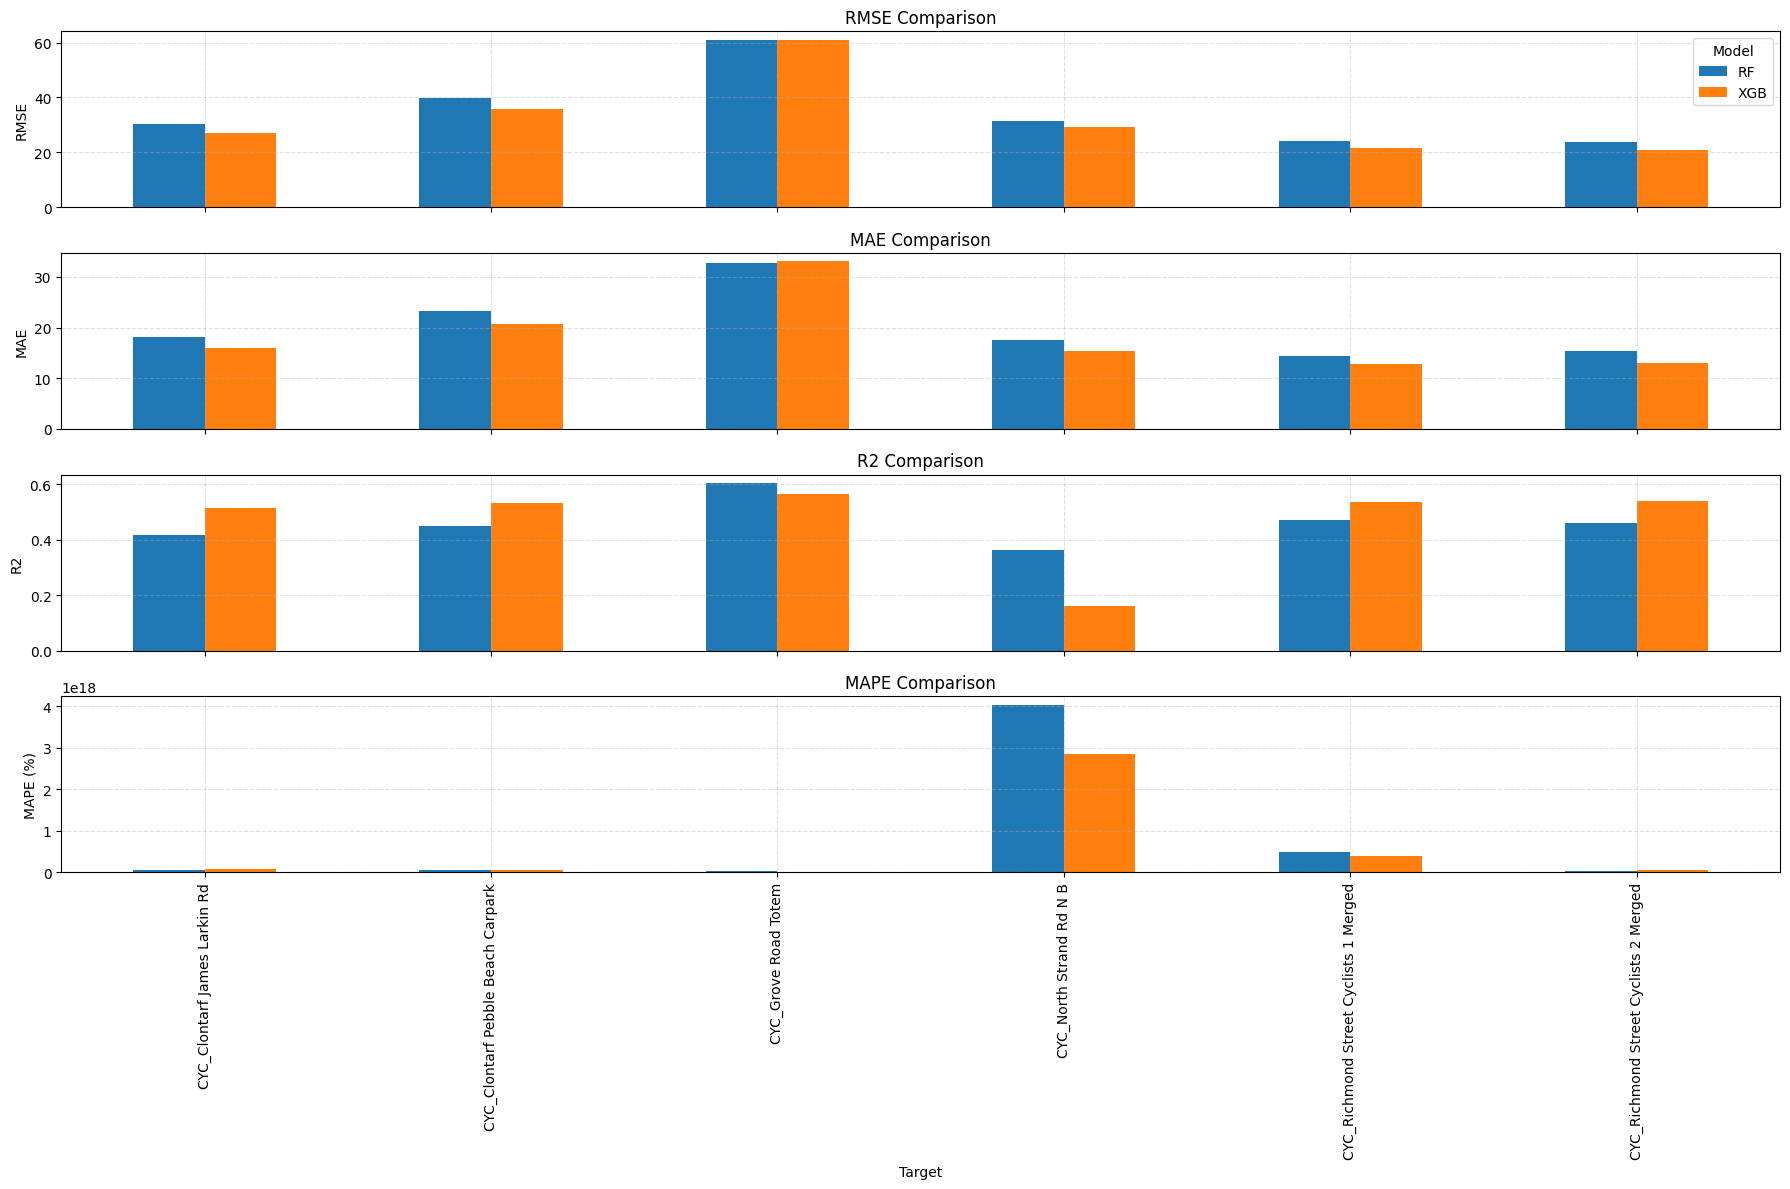

In [34]:
cyc_results = compare_performance(results_rf, results_xgb, prefix="CYC_")

In [35]:
# First row
first_ccyc = cyc_results.columns[0]

# Get and sort the rest of the columnns
sortedcc = sorted(cyc_results.columns[1:])

# Sort the dataframe keeping the column "Target" as first
cyc_results = cyc_results[[first_ccyc] + sortedcc]
cyc_results

,Target,MAE_mean_RF,MAE_mean_XGB,MAPE_mean_RF,MAPE_mean_XGB,R2_mean_RF,R2_mean_XGB,RMSE_mean_RF,RMSE_mean_XGB
0,CYC_Clontarf James Larkin Rd,18.066083,15.866757,6.750341e+16,6.994135e+16,0.416848,0.515749,30.269196,26.977750
1,CYC_Clontarf Pebble Beach Carpark,23.348787,20.648540,6.358856e+16,6.684588e+16,0.450805,0.533209,39.631178,35.599037
2,CYC_Grove Road Totem,32.657615,33.046586,2.112200e+16,9.670802e+15,0.603559,0.565359,61.025415,60.953238
3,CYC_North Strand Rd N B,17.627224,15.322597,4.027839e+18,2.852219e+18,0.363283,0.162600,31.494229,29.303943
4,CYC_Richmond Street Cyclists 1 Merged,14.468980,12.879582,4.785328e+17,3.950361e+17,0.471819,0.537144,24.025472,21.479287
5,CYC_Richmond Street Cyclists 2 Merged,15.282367,12.931020,3.860228e+16,5.337150e+16,0.459689,0.538482,23.795203,20.793194


### **6.2 FOOTFALL**

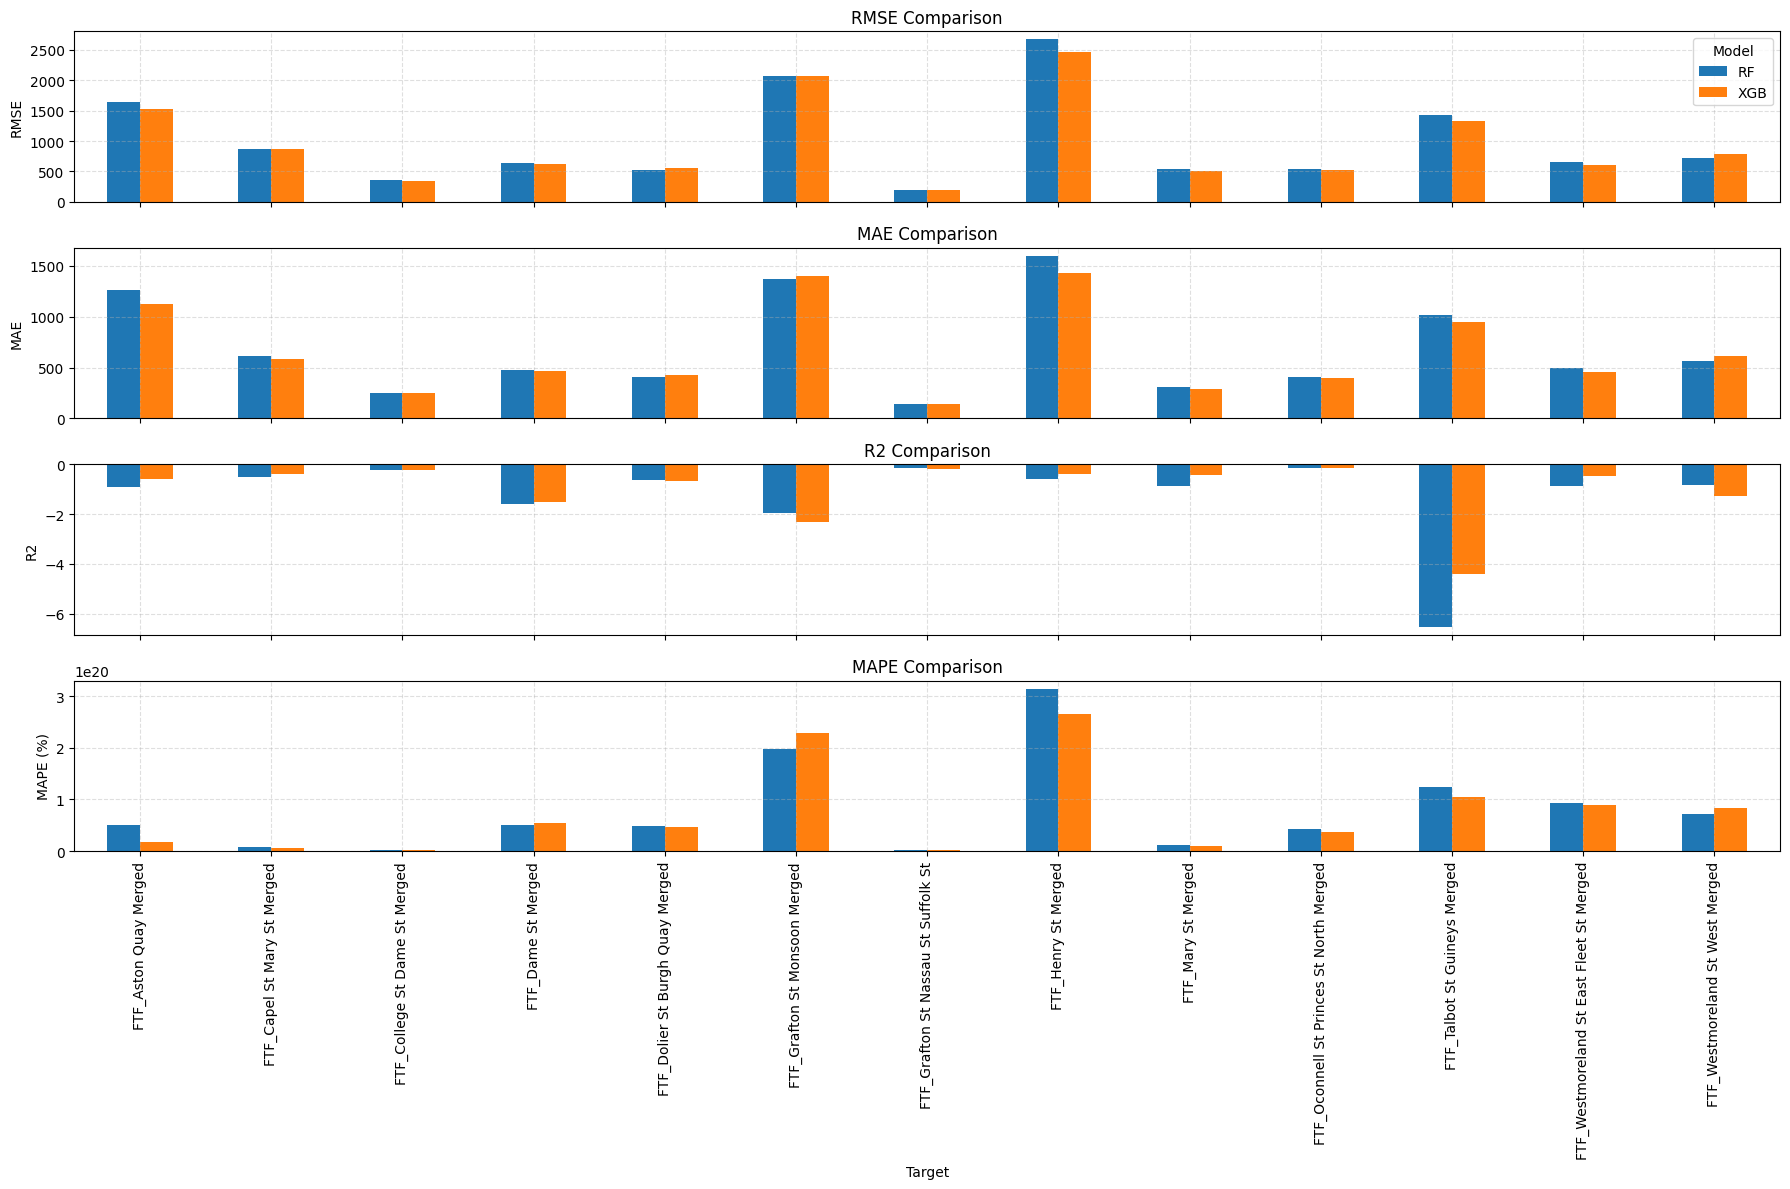

In [36]:
ftf_results = compare_performance(results_rf, results_xgb, prefix="FTF_")

In [37]:
# First row
first_c = ftf_results.columns[0]

# Get and sort the rest of the columnns
sortedc = sorted(ftf_results.columns[1:])

# Sort the dataframe keeping the column "Target" as first
ftf_results = ftf_results[[first_c] + sortedc]
ftf_results

,Target,MAE_mean_RF,MAE_mean_XGB,MAPE_mean_RF,MAPE_mean_XGB,R2_mean_RF,R2_mean_XGB,RMSE_mean_RF,RMSE_mean_XGB
0,FTF_Aston Quay Merged,1265.240656,1122.844474,5.161247e+19,1.850703e+19,-0.924090,-0.582382,1644.274630,1531.527292
1,FTF_Capel St Mary St Merged,614.780301,587.305144,8.430593e+18,6.977373e+18,-0.519282,-0.385436,867.289999,867.872292
2,FTF_College St Dame St Merged,252.481402,249.661680,2.233591e+18,2.160484e+18,-0.243454,-0.226177,356.292232,340.495357
3,FTF_Dame St Merged,480.867790,467.376280,5.067617e+19,5.385044e+19,-1.616189,-1.522613,643.333287,625.665359
4,FTF_Dolier St Burgh Quay Merged,409.477808,428.559389,4.954735e+19,4.717178e+19,-0.631596,-0.689110,527.185026,551.477104
5,FTF_Grafton St Monsoon Merged,1374.631806,1398.443037,1.974762e+20,2.295303e+20,-1.943777,-2.299100,2070.363295,2060.964874
6,FTF_Grafton St Nassau St Suffolk St,142.898383,141.711523,1.608277e+18,1.468394e+18,-0.141786,-0.194927,203.337803,201.036642
7,FTF_Henry St Merged,1599.017453,1428.943980,3.141191e+20,2.651844e+20,-0.590119,-0.395294,2668.356487,2458.711440
8,FTF_Mary St Merged,305.229111,292.440791,1.299550e+19,1.033384e+19,-0.858673,-0.418481,541.321868,513.311963
9,FTF_Oconnell St Princes St North Merged,404.968351,401.957839,4.273380e+19,3.722403e+19,-0.165479,-0.145923,535.815274,529.006583


In [38]:
baseline_results = pd.concat([ftf_results, cyc_results], ignore_index=True)
baseline_results

,Target,MAE_mean_RF,MAE_mean_XGB,MAPE_mean_RF,MAPE_mean_XGB,R2_mean_RF,R2_mean_XGB,RMSE_mean_RF,RMSE_mean_XGB
0,FTF_Aston Quay Merged,1265.240656,1122.844474,5.161247e+19,1.850703e+19,-0.924090,-0.582382,1644.274630,1531.527292
1,FTF_Capel St Mary St Merged,614.780301,587.305144,8.430593e+18,6.977373e+18,-0.519282,-0.385436,867.289999,867.872292
2,FTF_College St Dame St Merged,252.481402,249.661680,2.233591e+18,2.160484e+18,-0.243454,-0.226177,356.292232,340.495357
3,FTF_Dame St Merged,480.867790,467.376280,5.067617e+19,5.385044e+19,-1.616189,-1.522613,643.333287,625.665359
4,FTF_Dolier St Burgh Quay Merged,409.477808,428.559389,4.954735e+19,4.717178e+19,-0.631596,-0.689110,527.185026,551.477104
5,FTF_Grafton St Monsoon Merged,1374.631806,1398.443037,1.974762e+20,2.295303e+20,-1.943777,-2.299100,2070.363295,2060.964874
6,FTF_Grafton St Nassau St Suffolk St,142.898383,141.711523,1.608277e+18,1.468394e+18,-0.141786,-0.194927,203.337803,201.036642
7,FTF_Henry St Merged,1599.017453,1428.943980,3.141191e+20,2.651844e+20,-0.590119,-0.395294,2668.356487,2458.711440
8,FTF_Mary St Merged,305.229111,292.440791,1.299550e+19,1.033384e+19,-0.858673,-0.418481,541.321868,513.311963
9,FTF_Oconnell St Princes St North Merged,404.968351,401.957839,4.273380e+19,3.722403e+19,-0.165479,-0.145923,535.815274,529.006583


### **6.3 PREDICTIONS**

In [39]:
def predictions(predictor, data_geo, features, model_name="RF"):
    # For each target that has been trained
    preds_concat = []
    for target in data_geo["Target"].unique():
        if target not in predictor["models"]:
            continue
        print(f"Predicting for Target: {target} ...")

        # Filter target
        subset = data_geo[data_geo["Target"] == target].copy()
        X = subset[features]
        y_real = subset["Count"].copy()

        # Clean features with missing or empty values
        X = X.loc[:, X.std() > 0].dropna()

        # Obtain aligned date and time
        dates = subset.loc[X.index, "date and time"].reset_index(drop=True)
        y_real = y_real.loc[X.index].reset_index(drop=True)

        # Modelo y scaler
        model, scaler, _ = predictor["models"][target]
        X_scaled = scaler.transform(X)

        # Predict with whole numbers avoiding negative values
        y_pred = model.predict(X_scaled)
        y_pred = np.maximum(np.round(y_pred).astype(int), 0)

        # Predictions DataFrame
        predsDataFrame = pd.DataFrame({
            "date and time": dates,
            "Real": np.maximum(np.round(y_real).astype(int), 0),
            "Predicted": y_pred,
            "Target": target
        })

        preds_concat.append(predsDataFrame)
        print(predsDataFrame.head())

    # Concatenate all targets
    allpreds = pd.concat(preds_concat, ignore_index=True)
    return allpreds


In [40]:
 # Random Forest
preds_rf = predictions(rforest_predictor, data_geo, features, model_name="RF")
preds_rf = preds_rf.rename(columns={"Predicted": "RF"})
print(preds_rf.head(20))

Predicting for Target: CYC_Clontarf James Larkin Rd ...
         date and time  Real  Predicted                        Target
0  2019-01-01 00:00:00     0          0  CYC_Clontarf James Larkin Rd
1  2019-01-01 01:00:00     0          0  CYC_Clontarf James Larkin Rd
2  2019-01-01 02:00:00     0          0  CYC_Clontarf James Larkin Rd
3  2019-01-01 03:00:00     0          0  CYC_Clontarf James Larkin Rd
4  2019-01-01 04:00:00     0          0  CYC_Clontarf James Larkin Rd
Predicting for Target: CYC_Clontarf Pebble Beach Carpark ...
         date and time  Real  Predicted                             Target
0  2019-01-01 00:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
1  2019-01-01 01:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
2  2019-01-01 02:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
3  2019-01-01 03:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
4  2019-01-01 04:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
Predicting fo

In [41]:
# XGBoost
preds_xgb = predictions(xgb_predictor, data_geo, features, model_name="XGB")
preds_xgb = preds_xgb.rename(columns={"Predicted": "XGB"})
print(preds_xgb.head(20))

Predicting for Target: CYC_Clontarf James Larkin Rd ...
         date and time  Real  Predicted                        Target
0  2019-01-01 00:00:00     0          2  CYC_Clontarf James Larkin Rd
1  2019-01-01 01:00:00     0          0  CYC_Clontarf James Larkin Rd
2  2019-01-01 02:00:00     0          0  CYC_Clontarf James Larkin Rd
3  2019-01-01 03:00:00     0          0  CYC_Clontarf James Larkin Rd
4  2019-01-01 04:00:00     0          0  CYC_Clontarf James Larkin Rd
Predicting for Target: CYC_Clontarf Pebble Beach Carpark ...
         date and time  Real  Predicted                             Target
0  2019-01-01 00:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
1  2019-01-01 01:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
2  2019-01-01 02:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
3  2019-01-01 03:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
4  2019-01-01 04:00:00     0          0  CYC_Clontarf Pebble Beach Carpark
Predicting fo

 ## **7. RESULTS TO AZURE BLOB STORAGE**

In [42]:
def save_blob(data, filename):
    try:
        blob_name = f"{CONTAINER_NAME}/{filename}"
        csv_data = data.to_csv(index=False)
        with fs.open(blob_name, "w") as f:
            f.write(csv_data)
        print(f"Saved to {blob_name}")
    except Exception as e:
        print(f"Error saving data to blob storage: {str(e)}")
        return False

In [45]:
CONTAINER_NAME = "results"

# Evaluation metrics
save_blob(baseline_results, "rbaseline.csv")

Saved to results/rbaseline.csv


In [46]:
# Predictions
CONTAINER_NAME = "predictions"

save_blob(preds_rf, "pred_rf.csv")
save_blob(preds_xgb, "pred_xgb.csv")

Saved to predictions/pred_rf.csv
Saved to predictions/pred_xgb.csv
